In [16]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Join all dataset files found in your logs folder
log_files = glob.glob("training_logs/grid_search_*.csv")
print(len(log_files))
if len(log_files) == 1:
    df = pd.read_csv(log_files[0])
else:
    df_list = [pd.read_csv(f) for f in log_files]
    df = pd.concat(df_list, ignore_index=True)

# 2. Basic cleaning and sorting
df = df.sort_values(by=['Depth', 'Filters', 'BS', 'LR', 'Epoch'])
df_2_6 = df[df['Depth'] != 1]
# 3. Identify the "Best" epoch for each combination (lowest Test Error)
best_runs = df.loc[df.groupby(['Depth', 'Filters', 'BS', 'LR'])['Test_Err'].idxmin()]

print(f"Total Epochs Analyzed: {len(df)}")
print(f"Unique Hyperparameter Combinations: {len(best_runs)}")
best_runs = best_runs[best_runs['Depth'] != 1]
best_runs[['Depth', 'Filters', 'BS', 'LR', 'Test_Err']].head()


4
Total Epochs Analyzed: 2892
Unique Hyperparameter Combinations: 42


,Depth,Filters,BS,LR,Test_Err
417,2,16,16,0.0005,0.340495
389,2,16,16,0.0010,0.293670
476,2,16,32,0.0005,0.305879
442,2,16,32,0.0010,0.312279
2517,2,16,64,0.0005,0.324308


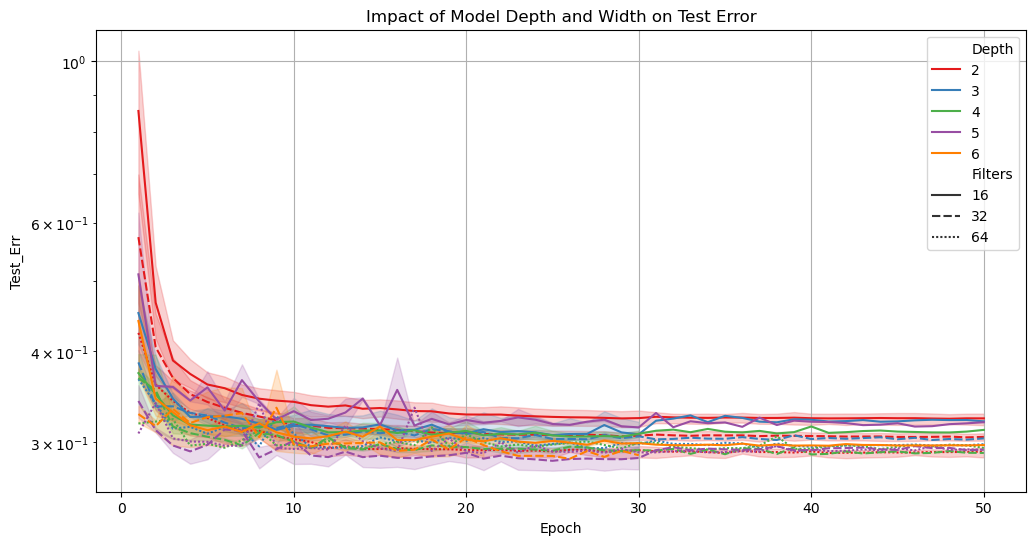

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_2_6, x='Epoch', y='Test_Err', hue='Depth', style='Filters', palette="Set1")
plt.title("Impact of Model Depth and Width on Test Error")
plt.yscale('log') # Use log scale if errors vary significantly
plt.grid(True)
plt.show()

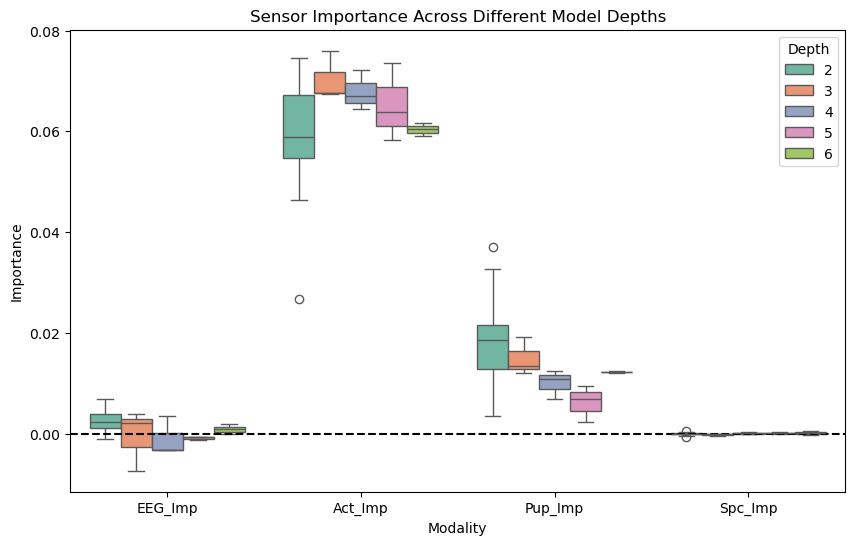

In [18]:
# Melt importance scores for easier plotting
# These were calculated with ablation testing in Turn
imp_cols = ['EEG_Imp', 'Act_Imp', 'Pup_Imp', 'Spc_Imp']
# melted DataFrame head:
melted_imp = best_runs.melt(id_vars=['Depth'], value_vars=imp_cols, 
                            var_name='Modality', value_name='Importance')

plt.figure(figsize=(10, 6))
# Updated from the default to a bright qualitative palette.
# A built-in discrete qualitative palette like "Set2" makes the depth categories much clearer.
sns.boxplot(data=melted_imp, x='Modality', y='Importance', hue='Depth', palette="Set2")
plt.title("Sensor Importance Across Different Model Depths")
plt.axhline(0, color='black', linestyle='--')
plt.show()